| Model          | شنو كيدير للـ coefficients |
| -------------- | -------------------------- |
| Ridge (L2)     | كيخلّيهم صغار ولكن ≠ 0     |
| **Lasso (L1)** | **كيقدر يطيّحهم لـ 0**  |


- ida kanet 3ndk bzaf dyal features w bghiti t3rf ach menhom mohimmin, st3ml Lasso
- feature = 0 => ma3ndkch 7aja t9oul 3liha 3la hadak feature lol

# Lesson 6: Lasso Regression (L1)

## Objective
- Fahm Lasso Regression (L1 Regularization)
- Fham far9 bin Ridge w Lasso
- N9arn bin Ridge w Lasso f examples visuels

## Intuition

Ridge kat9oul lel model: "kolch yb9a mais sghar"
Lasso kat9oul lel model: "khalli ghir li mohim w 7ayed dek chi li ma mohimch"

Goal:
- n7ydou features li ma3ndhomch relation b target
- nsahlou model
- nhbsou overfitting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
X = np.array([40, 50, 60, 70, 80, 90, 100]).reshape(-1, 1)
y = np.array([78, 102, 118, 145, 158, 182, 205])

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
poly_6 = PolynomialFeatures(degree=6)

X_train_p6 = poly_6.fit_transform(X_train)
X_test_p6 = poly_6.transform(X_test)

## 3andna bzef dyal features, w bghina n3rfou ach menhom mohimmin, donc nst3mlou Lasso

Ridge

In [5]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_p6, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_ridge.py:254: UserWarning: Singular matrix in solving dual problem. Using least-squares solution instead.
  warnings.warn(


Ridge()

Lasso

In [12]:
lasso = Lasso(alpha=10)
lasso.fit(X_train_p6, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.985e+01, tolerance: 3.969e-01
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=10)

On compare les coeff dyal Ridge w Lasso

In [13]:
print("Ridge coefficients:")
print(ridge.coef_)

print("\nLasso coefficients:")
print(lasso.coef_)

Ridge coefficients:
[ 0.00000000e+00  2.56763730e-10  2.30987319e-08  1.30748647e-06
  4.41536106e-05 -8.37968215e-07  4.16524770e-09]

Lasso coefficients:
[ 0.00000000e+00  0.00000000e+00  2.39175437e-02 -6.75407520e-05
 -3.35108945e-07 -2.72067877e-10  1.67213538e-11]


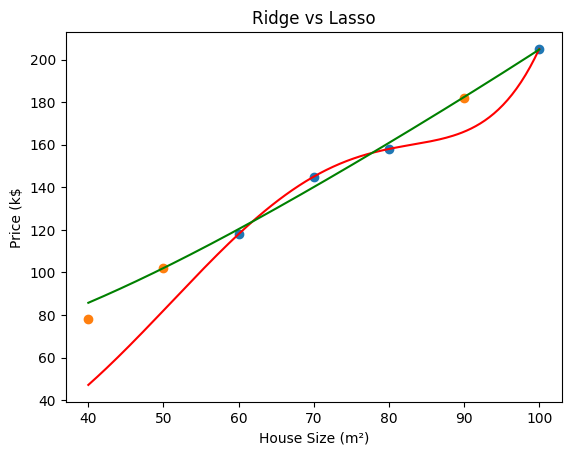

In [14]:
X_line = np.linspace(40, 100, 200).reshape(-1, 1)
X_line_p6 = poly_6.transform(X_line)

y_ridge = ridge.predict(X_line_p6)
y_lasso = lasso.predict(X_line_p6)

plt.scatter(X_train, y_train)
plt.scatter(X_test, y_test)

plt.plot(X_line, y_ridge, color='red')
plt.plot(X_line, y_lasso, color='green')

plt.xlabel("House Size (m²)")
plt.ylabel("Price (k$")
plt.title("Ridge vs Lasso")
plt.show()

In [9]:
print("Ridge MSE:",
      mean_squared_error(y_test, ridge.predict(X_test_p6)))

print("Lasso MSE:",
      mean_squared_error(y_test, lasso.predict(X_test_p6)))

Ridge MSE: 533.9584266584342
Lasso MSE: 18.353633394710318


## Note: 

des fois lasso ykon mieux w des fois ridge ykon mieux tni, donc mknch chi gagnant f kolchi

Lasso ky7yd features li ma3ndhomch 7aja y9oul 3liha, w hadchi kay3awn f interpretability dyal model
| Model          | شنو كيدير للـ coefficients |
| -------------- | -------------------------- |
| Ridge (L2)     | كيخلّيهم صغار ولكن ≠ 0     |
| **Lasso (L1)** | **كيقدر يطيّحهم لـ 0**  |
- ida kanet 3ndk bzaf dyal features w bghiti t3rf ach menhom mohimmin, st3ml Lasso
- Lasso moufid mli ykon bzef dyal features, w b3dhm useless
- interpretability dyal model katwli ashal bzaaf 

## Lasso performs feature selection, Ridge performs feature shrinking

Lasso yna9i w Ridge yrabi

yla bghina nfhmou model mzyan, Lasso hya lbest option 7it kat7yd features li ma3ndhomch 7aja y9oul 3liha

| Part       | Role                |
| ---------- | -------------------- |
| Train      | Yt3lm               |
| Validation | Nkhtaro model + alpha |
| Test       | Eval Finale        |
